In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path
import functools

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import lsstypes as types
code_dir = f'{os.getenv('HOME')}/cai-dr2-clustering-products/clustering_statistics/'
sys.path.insert(0,code_dir)
import tools
import plotting_tools

In [3]:
plot_dir = Path('_plots')
plot_dir.mkdir(exist_ok=True)
ext = 'png'

In [4]:
def fill_blocks(nums, block_size):
    """
    Split integers into blocks of size `block_size` and fill missing
    integers only within blocks that already contain at least one value.
    """
    if not nums:
        return []
        
    nums = sorted(set(nums))
    
    # Group numbers by block index
    blocks = {}
    for n in nums:
        block_index = n // block_size
        if block_index not in blocks:
            start = block_index * block_size
            end = start + block_size
            blocks[block_index] = list(range(start, end))

    # Return blocks ordered by block index
    return [blocks[i] for i in sorted(blocks)]

def blocks_to_ranges(blocks):
    """
    Convert filled blocks into [start, end, step] format.
    """
    ranges = []
    for block in blocks:
        start = block[0]
        end = block[-1] + 1
        step = len(block)

        ranges.append([start, end, step])

    return ranges
    
def make_cases(start=None, stop=None, step=50, version=None, ranges=None, exclude=None, reference=None):
    """
    generate dictionary of cases for blocks of mocks
    """
    cases = {}

    # Add reference FIRST
    if reference is not None:
        if len(reference) == 2:
            s, e = reference
            st = step
        elif len(reference) == 3:
            s, e, st = reference
        else:
            raise ValueError("reference must be [start, end] or [start, end, step]")

        key = f"{s}-{e-1}"
        imocks = s + np.arange(st)
        imocks = imocks[~np.isin(imocks, exclude)]
        cases[key] = {'version': version, 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': imocks}
        
    # If explicit ranges are provided, use them
    if ranges is not None:
        for r in ranges:
            if len(r) == 2:
                s, e = r
                st = step
            elif len(r) == 3:
                s, e, st = r
            else:
                raise ValueError("Each range must be [start, end] or [start, end, step]")

            key = f"{s}-{e-1}"
            imocks = s + np.arange(st)
            imocks = imocks[~np.isin(imocks,exclude)]
            cases[key] = {'version': version, 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False,'imocks': imocks}

    else:
        if start is None or stop is None:
            raise ValueError("Provide either (start, stop) or ranges")

        for s in range(start, stop, step):
            e = s + step - 1
            key = f"{s}-{e-1}"
            imocks = s + np.arange(step)
            imocks = imocks[~np.isin(imocks,exclude)]
            cases[key] = {'version': version, 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False,'imocks': imocks}
    return cases

def custom_get_stats_fn(get_stats_fn, imock=None, include_dubious=False, **kwargs):
    # custom function to load stats
    if imock is None:
        return get_stats_fn(**kwargs)
    else:
        if imock == '*':
            fns = [get_stats_fn(imock=jmock, **kwargs) for jmock in range(1501)] 
        elif isinstance(imock, list):
            fns = [get_stats_fn(imock=jmock, **kwargs) for jmock in imock]
        else:
            fns = [get_stats_fn(imock=imock, **kwargs)]    
        if include_dubious:
            fns += [str(fn).replace('mock','dubious_mock') for fn in fns]
        fns = [fn for fn in fns if os.path.exists(fn)]
        return fns

# Checks on GLAM-Uchuu_v2 (no dubious realizations included)

In [6]:
version = 'glam-uchuu-v2-altmtl'
analysis = 'full_shape'
project = f'{analysis}/base'
region  = 'GCcomb'
tracers = ['LRG', 'ELG_LOPnotqso', 'QSO']
# tracers = ['ELG_LOPnotqso']
stats_dir = Path(str(tools.base_stats_dir).replace('global','dvs_ro'))

ells4pk = (0,2)
ells4xi = [0,2,4]
ells4bk = ((0,0,0), (2,0,2))

In [6]:
# !ls /global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/glam-uchuu-v2-altmtl/

In [7]:
get mock ids of existing measurements
stats_kws = dict(stats_dir=stats_dir,project=project,version=version,kind='mesh2_spectrum',tracer='LRG',zrange=(0.4,0.6),region=region,weight='default-FKP')
rexists, missing, unreadable = tools.checks_if_exists_and_readable(get_fn=functools.partial(tools.get_stats_fn, **stats_kws), test_if_readable=True, imock=np.arange(0,1500))
print(len(rexists[1]['imock']))

step = 50
blocks = fill_blocks(rexists[1]['imock'], step)
blocks = np.array(blocks_to_ranges(blocks))
blocks = np.array_split(blocks,5)
blocks

In [ ]:
bad_imocks = None # np.concatenate([375+np.arange(25),[211,280]])
reference = None
ref_range = [150,200,step]

scaling='kpk'
# scaling='loglog'
# kinds = ['mesh2_spectrum','mesh3_spectrum_sugiyama-diagonal']
# kinds = ['mesh3_spectrum_sugiyama-diagonal']
kinds = ['mesh2_spectrum']

pp = PdfPages(plot_dir / 'check_glam-uchuu-v2-altmlt.pdf')
for kind in kinds:
    ells = ells4pk if 'mesh2' in kind else ells4bk
    for iblocks in blocks:
        cases = make_cases(ranges=iblocks, version=version, exclude=bad_imocks, reference=ref_range)
        colors = dict(zip(cases, [f'C{i}' for i in range(len(cases))]))
        linestyles = dict(zip(cases, [':', ':','-.']+[':']*(len(cases)-3)))
        plot_kws = dict(colors=colors,linestyles=linestyles,scaling=scaling,stats_dir=stats_dir,project=project,plot_all=True,rebin=1)
        
        for tracer in tracers:
            zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
            nrows  = len(ells) * 2
            ncols  = len(zranges)
            figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
            for iz, zrange in enumerate(zranges):    
                plot_kws = plot_kws|dict(reference=reference, figure=figure, ax_col=iz, ells=ells)
                plotting_tools.plot_stats(kind, cases, tracer, zrange, region, **plot_kws)
                
            figure[0].tight_layout()
            basename = f'checks_{kind}_{version}_{tracer}_{region}.{ext}'
            # figure[0].savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            pp.savefig(figure[0],bbox_inches='tight')
            plt.show()
            plt.close(figure[0])
            print()
pp.close()

In [8]:
# generate list of good measurements to use for covariance estimation using glam-uchuu-v2-altmtl
versions = ['glam-uchuu-v2-altmtl']
_exists = []
for tracer in ['LRG', 'ELG_LOPnotqso']:
    for version in versions:
        exists, missing = tools.checks_if_exists_and_readable(get_fn=functools.partial(tools.get_catalog_fn, tracer=tracer[0] if isinstance(tracer, (list, tuple)) else tracer,
                                                                                       region='NGC', version=version), test_if_readable=False, imock=np.arange(1500))[:2]
        _exists.append(exists)
        catalog_imocks = exists[1]['imock']
        print(len(catalog_imocks))
        print()

print(len(_exists[0][1]['imock']),len(_exists[1][1]['imock']))
# We find that LRG clustering catalogs are misssing for the following realizations 
bad_imocks = set(_exists[1][1]['imock']) - set(_exists[0][1]['imock']) 
bad_imocks = [int(i) for i in bad_imocks]
print(len(bad_imocks),bad_imocks)

# We also find the following realizations to be significant outliers (except 543, this one 
# is labeled because the ELG clustering catalogs do not have redshifts for z>1.1).
bad_imocks = np.array(sorted(np.concatenate([350 + np.arange(50), [280,543,1275], bad_imocks])), dtype=int)


# then the realizations to use for covariance estimation are 
imocks = np.array([int(i) for i in _exists[1][1]['imock']])
bad_imocks  = bad_imocks[np.isin(bad_imocks,imocks)]
good_imocks = imocks[~np.isin(imocks,bad_imocks)]
print(len(good_imocks))


# np.savetxt('../helper_scripts/glam-uchuu-v2-altmtl_dark-time_imocks_for_covariance.txt',good_imocks,fmt='%i')
# np.savetxt('../helper_scripts/dubious_glam-uchuu-v2-altmtl.txt',bad_imocks,fmt='%i')

930

942

930 942
12 [1034, 1035, 1036, 1037, 1038, 1039, 1008, 1009, 1040, 1041, 1012, 1013]
878


# Checks on GLAM-Uchuu_v2

In [6]:
version = 'glam-uchuu-v2-altmtl'
analysis = 'full_shape'
project = f'{analysis}/base'
region  = 'GCcomb'
tracers = ['ELG_LOPnotqso']
# tracers = ['ELG_LOPnotqso']
stats_dir = Path(str(tools.base_stats_dir).replace('global','dvs_ro'))

ells4pk = (0,2)
ells4xi = [0,2,4]
ells4bk = ((0,0,0), (2,0,2))

In [8]:
# stats_kws = dict(stats_dir=stats_dir, project=project, kind='mesh2_spectrum', basis='sugiyama-diagonal', 
#                  version=version, tracer='QSO', zrange=(0.8,2.1), weight='default-FKP', region=region)

# # this will find all mock fns (including dubious realizations)
# fns = custom_get_stats_fn(get_stats_fn=functools.partial(tools.get_stats_fn, **stats_kws), imock='*', include_dubious=True) 
# print('QSO', version, (0.8,2.1), 'mesh2_spectrum',len(fns))

# # now remove dubious identifier from fn
# fns = [str(fn).replace('dubious_mock','mock') for fn in fns]

# # get imocks
# imocks = [int(fn.split('mock')[-1].split('/')[0]) for fn in fns]
# sort_indices = np.argsort(imocks)
# fns = [fns[ind] for ind in sort_indices]

# # check for repeats
# unique, counts = np.unique(imocks, return_counts=True)
# repeated = unique[counts != 1] # because they were previously dubious realizations
# print(len(imocks)-len(repeated))

# imocks = unique
# print(len(imocks))

In [7]:
# step = 50
# blocks = fill_blocks(list(imocks), step)
# blocks = np.array(blocks_to_ranges(blocks))
# blocks = np.array_split(blocks,5)
# blocks

In [10]:
# stats_kws = dict(stats_dir=stats_dir, project=project, kind='mesh2_spectrum', basis='sugiyama-diagonal', 
#                  version=version, tracer='QSO', zrange=(0.8,2.1), weight='default-FKP', region=region)

# # this will find all mock fns (excluding dubious realizations)
# fns = custom_get_stats_fn(get_stats_fn=functools.partial(tools.get_stats_fn, **stats_kws), imock='*') 
# print('QSO', version, (0.8,2.1), 'mesh2_spectrum',len(fns))

# good_imocks = [int(str(fn).split('mock')[-1].split('/')[0]) for fn in fns]
# len(good_imocks)

QSO glam-uchuu-v2-altmtl (0.8, 2.1) mesh2_spectrum 983


983

In [ ]:
blocks = [[0,1500,1500],[350,400,50]]

WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.


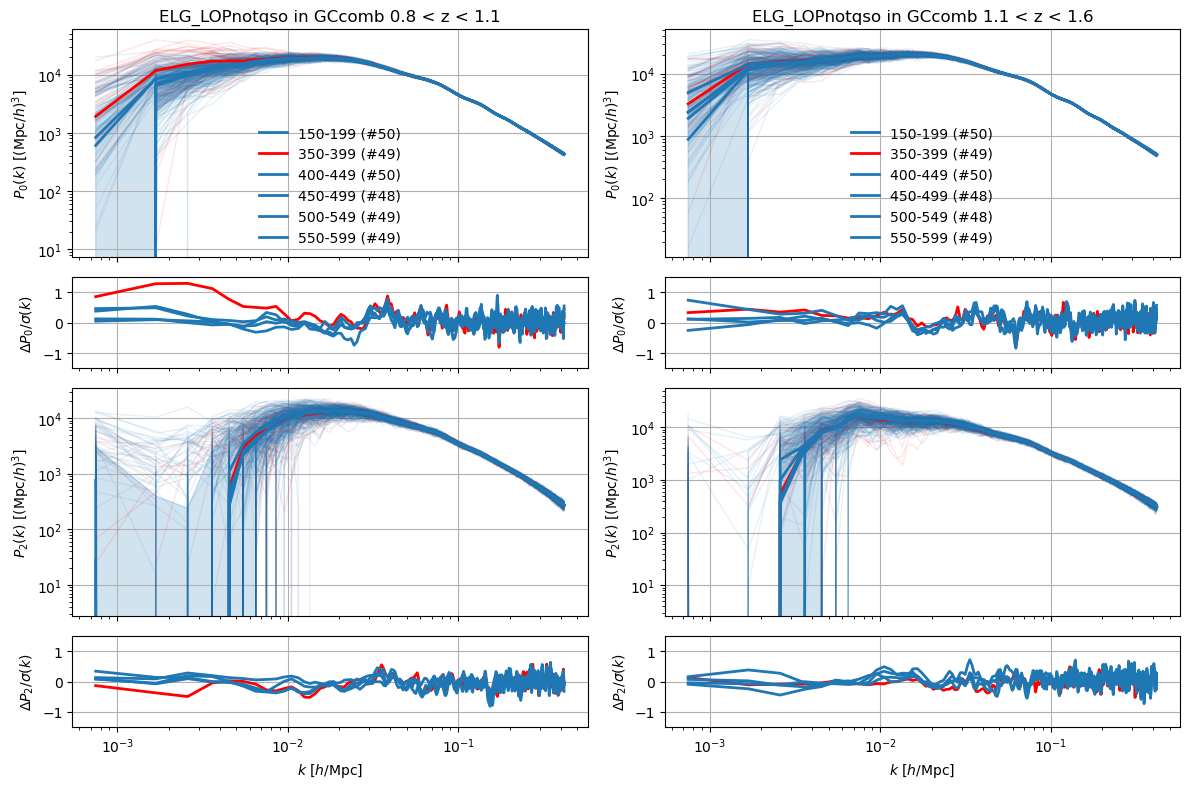

In [10]:
bad_imocks = None # np.concatenate([375+np.arange(25),[211,280]])
reference = None
ref_range = [150,200,step]

# scaling='kpk'
scaling='loglog'
# kinds = ['mesh2_spectrum','mesh3_spectrum_sugiyama-diagonal']
# kinds = ['mesh3_spectrum_sugiyama-diagonal']
kinds = ['mesh2_spectrum']

pp = PdfPages(plot_dir / 'check_glam-uchuu-v2-altmlt_including_dubious.pdf')
for kind in kinds:
    ells = ells4pk if 'mesh2' in kind else ells4bk
    for iblocks in blocks[1:2]:
        cases = make_cases(ranges=iblocks, version=version, exclude=bad_imocks, reference=ref_range)
        # colors = dict(zip(cases, [f'C{i}' for i in range(len(cases))]))
        # linestyles = dict(zip(cases, [':', ':','-.']+[':']*(len(cases)-3)))
        colors = dict(zip(cases, ['C0','red','C0','C0','C0','C0']))
        linestyles = dict(zip(cases, ['-']*len(cases)))
        plot_kws = dict(colors=colors,linestyles=linestyles,scaling=scaling,stats_dir=stats_dir,project=project,
                        plot_all=True,rebin=1,include_dubious=True)
        
        for tracer in tracers:
            zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
            nrows  = len(ells) * 2
            ncols  = len(zranges)
            figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
            for iz, zrange in enumerate(zranges):    
                plot_kws = plot_kws|dict(reference=reference, figure=figure, ax_col=iz, ells=ells)
                plotting_tools.plot_stats(kind, cases, tracer, zrange, region, **plot_kws)
                
            figure[0].tight_layout()
            # basename = f'checks_{kind}_{version}_{tracer}_{region}.{ext}'
            # figure[0].savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            pp.savefig(figure[0],bbox_inches='tight')
            plt.show()
            plt.close(figure[0])
            print()
pp.close()

# More checks

In [5]:
version = 'glam-uchuu-v2-altmtl'
analysis = 'full_shape'
project = f'{analysis}/base'
region  = 'GCcomb'
tracers = ['ELG_LOPnotqso']
zrange = (0.8,1.1)
stats_dir = Path(str(tools.base_stats_dir).replace('global','dvs_ro'))

ells4pk = (0,2)
ells4xi = [0,2,4]
ells4bk = ((0,0,0), (2,0,2))

In [10]:
# measumerents to compare
reference = '0-1499'
im = np.arange(350,400)
im = im[~np.isin(im,np.arange(360,375))]
imocks_batches = [np.arange(0,1500),np.arange(350,400),im,np.arange(360,375),np.arange(350,360),np.arange(375,400)]
cases = {}
for i, imocks in enumerate(imocks_batches):
    # print(imocks)
    if i != 0:
        include_dubious = True
    else: 
        include_dubious = False
    if i == 1:
        cases[f'{imocks[0]}-{imocks[-1]} (all)'] = {'version': version, 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': imocks, 'include_dubious': include_dubious}
    elif i == 2:
        cases[f'{imocks[0]}-{imocks[-1]} (some)'] = {'version': version, 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': imocks, 'include_dubious': include_dubious}
    else:
        cases[f'{imocks[0]}-{imocks[-1]}'] = {'version': version, 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': imocks, 'include_dubious': include_dubious}
# # colors and linestyles
colors = dict(zip(cases, [f'C{i}' for i in range(len(cases))]))
linestyles = dict(zip(cases, ['-', '--','-.',':',':',':',':']))
cases

{'0-1499': {'version': 'glam-uchuu-v2-altmtl',
  'weight': 'default-FKP',
  'extra': '',
  'cut': False,
  'auw': False,
  'imocks': array([   0,    1,    2, ..., 1497, 1498, 1499], shape=(1500,)),
  'include_dubious': False},
 '350-399 (all)': {'version': 'glam-uchuu-v2-altmtl',
  'weight': 'default-FKP',
  'extra': '',
  'cut': False,
  'auw': False,
  'imocks': array([350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362,
         363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375,
         376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388,
         389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399]),
  'include_dubious': True},
 '350-399 (some)': {'version': 'glam-uchuu-v2-altmtl',
  'weight': 'default-FKP',
  'extra': '',
  'cut': False,
  'auw': False,
  'imocks': array([350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 375, 376, 377,
         378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390,
         391, 392, 393, 394, 395

WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.


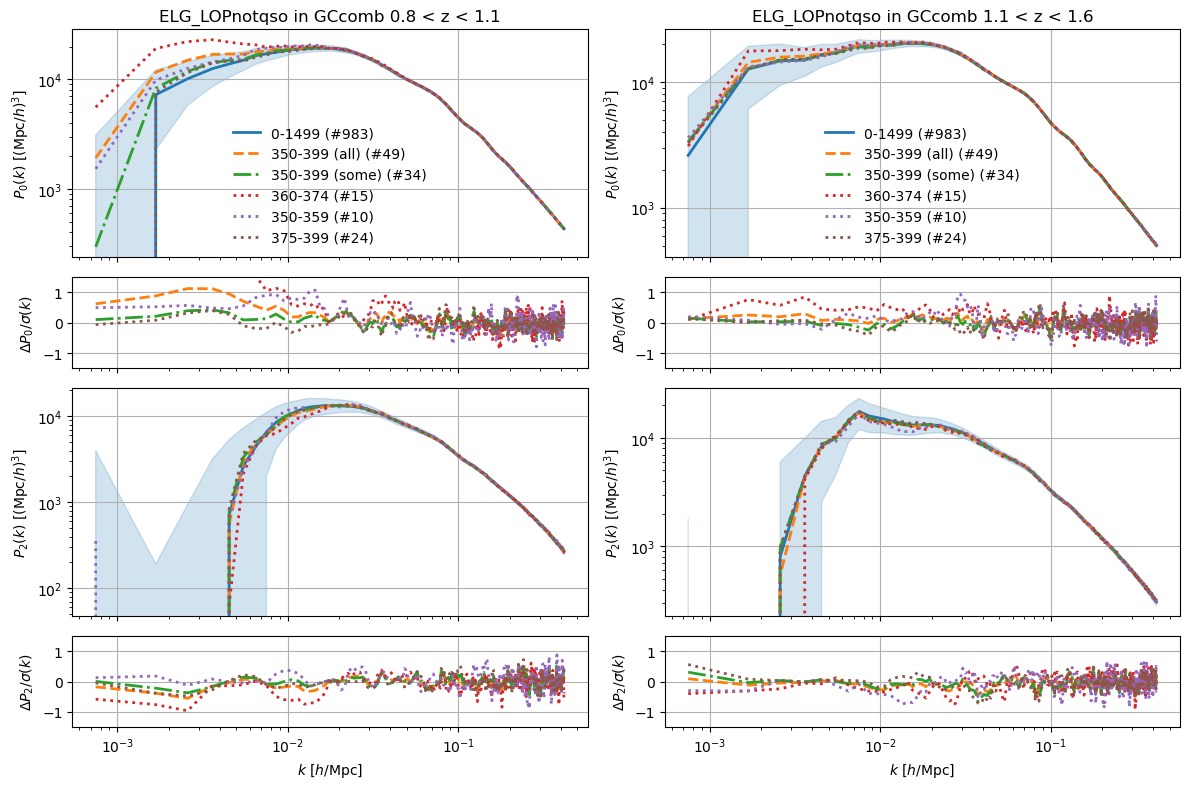

In [11]:
# figures with power spectra
# scaling='kpk'
scaling='loglog'

plot_kws = dict(colors=colors,linestyles=linestyles,scaling=scaling,stats_dir=stats_dir,project=project,legend_ncol=1)
for tracer in tracers:
    zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
    nrows  = len(ells4pk) * 2
    ncols  = len(zranges)
    figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells4pk)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1] * len(ells4pk)})
    for iz, zrange in enumerate(zranges):    
        plot_kws = plot_kws|dict(reference=reference, figure=figure, ax_col=iz, ells=ells4pk)
        plotting_tools.plot_stats('mesh2_spectrum', cases, tracer, zrange, region, **plot_kws)
    plt.tight_layout()
    basename = f'checks_loglog_pk_{version}_{tracer}_{region}.{ext}'
    figure[0].savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()
    print()

In [12]:
# measumerents to compare
reference = '0-1499'
im = np.arange(350,400)
im = im[~np.isin(im,np.arange(360,375))]
imocks_batches = [np.arange(0,1500),np.arange(350,360),np.arange(375,400),np.arange(360,375)]
cases = {}
for i, imocks in enumerate(imocks_batches):
    # print(imocks)
    if i != 0:
        include_dubious = True
    else: 
        include_dubious = False
    if i == 1:
        cases[f'{imocks[0]}-{imocks[-1]} (all)'] = {'version': version, 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': imocks, 'include_dubious': include_dubious}
    elif i == 2:
        cases[f'{imocks[0]}-{imocks[-1]} (some)'] = {'version': version, 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': imocks, 'include_dubious': include_dubious}
    else:
        cases[f'{imocks[0]}-{imocks[-1]}'] = {'version': version, 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False, 'imocks': imocks, 'include_dubious': include_dubious}
# # colors and linestyles
colors = dict(zip(cases, [f'C{i}' for i in range(len(cases))]))
linestyles = dict(zip(cases, ['-', '--','-.',':',':',':',':']))
cases

{'0-1499': {'version': 'glam-uchuu-v2-altmtl',
  'weight': 'default-FKP',
  'extra': '',
  'cut': False,
  'auw': False,
  'imocks': array([   0,    1,    2, ..., 1497, 1498, 1499], shape=(1500,)),
  'include_dubious': False},
 '350-359 (all)': {'version': 'glam-uchuu-v2-altmtl',
  'weight': 'default-FKP',
  'extra': '',
  'cut': False,
  'auw': False,
  'imocks': array([350, 351, 352, 353, 354, 355, 356, 357, 358, 359]),
  'include_dubious': True},
 '375-399 (some)': {'version': 'glam-uchuu-v2-altmtl',
  'weight': 'default-FKP',
  'extra': '',
  'cut': False,
  'auw': False,
  'imocks': array([375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387,
         388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399]),
  'include_dubious': True},
 '360-374': {'version': 'glam-uchuu-v2-altmtl',
  'weight': 'default-FKP',
  'extra': '',
  'cut': False,
  'auw': False,
  'imocks': array([360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372,
         373, 374]),
  'incl

WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.
WARNING! Using measurements from dubious realizations.


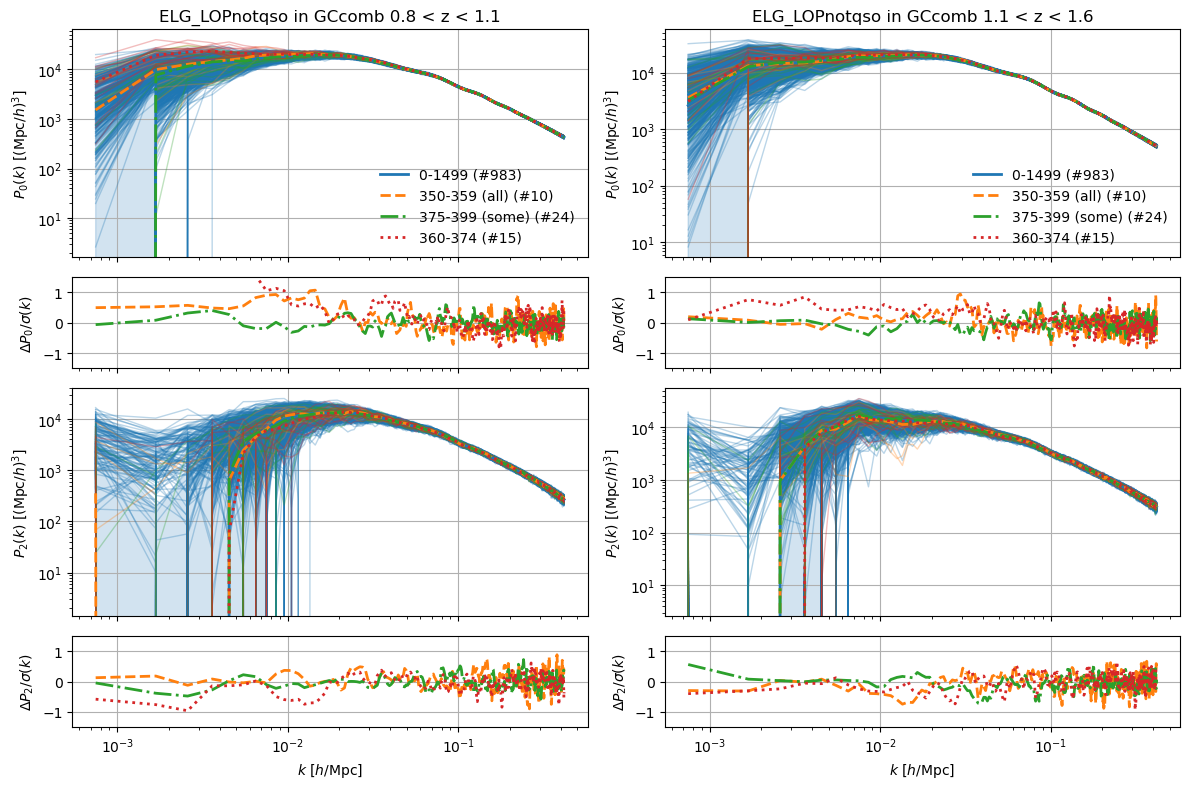

In [15]:
# figures with power spectra
# scaling='kpk'
scaling='loglog'

plot_kws = dict(colors=colors,linestyles=linestyles,scaling=scaling,stats_dir=stats_dir,project=project,legend_ncol=1,plot_all=True)
for tracer in tracers:
    zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
    nrows  = len(ells4pk) * 2
    ncols  = len(zranges)
    figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells4pk)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1] * len(ells4pk)})
    for iz, zrange in enumerate(zranges):    
        plot_kws = plot_kws|dict(reference=reference, figure=figure, ax_col=iz, ells=ells4pk)
        plotting_tools.plot_stats('mesh2_spectrum', cases, tracer, zrange, region, **plot_kws)
    plt.tight_layout()
    basename = f'checks_loglog_pk_{version}_{tracer}_{region}.{ext}'
    figure[0].savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()
    print()